In [1]:
%load_ext autoreload
%autoreload 2
cmd = "C"
import sys
parent_dir = "C:/Users/yuhang.hou/projects/holidays/poc_backtester/data_pipeline/universal"

import json
import pandas as pd
import os
import pickle
sys.path.append(parent_dir)
holidays_path = "C:/Users/yuhang.hou/projects/holidays"
sys.path.append(holidays_path)
from backtester import *
from utils import *

last_trading_days = get_last_trading_days(cmd)
ltds = {k:pd.to_datetime(v) for k,v in last_trading_days.items()}

business_days = load_business_days_cmd(cmd)
business_days = sorted(business_days)

def process_results(results):
    res =[]
    for date, data in results.items():
        temp= { }
        temp['date'] = date
        temp['level'] = data['level']
        temp['tc'] = data['tc']
        res.append(temp)
    res = pd.DataFrame(res)
    res = res.set_index('date')
    res['tc_cumsum'] = res['tc'].cumsum()
    return res

def load_future_data(data_path = f'./data/{cmd}',values = 'close'):
    files = [f for f in os.listdir(data_path) if f.endswith('.csv')]
    dfs = (pd.read_csv(os.path.join(data_path, file)).assign(
        contract=file.replace('.csv', ''),
        date=lambda df: pd.to_datetime(df['date'])
    ) for file in files)

    big_df = pd.concat(dfs, ignore_index=True)
    pivot_df = big_df.pivot(index='date', columns='contract', values= values)

    return pivot_df

contract_df = load_future_data(f'C:/Users/yuhang.hou/projects/holidays/poc_backtester/data/future/cme/{cmd}',['close'])
contract_df = contract_df.ffill()
# contract_df.head()
contract_df.dropna(how='all', inplace=True)
start_date = '2013-07-01'
end_date = '2026-01-01'

In [2]:
contract_df.tail(5)

close                                                             \
contract       F01     F02    H00    H01    H02     H03     H04    H05    H06   
date                                                                            
2026-01-02  224.75  200.75  215.0  214.5  200.5  231.75  296.25  214.5  228.0   
2026-01-05  224.75  200.75  215.0  214.5  200.5  231.75  296.25  214.5  228.0   
2026-01-06  224.75  200.75  215.0  214.5  200.5  231.75  296.25  214.5  228.0   
2026-01-07  224.75  200.75  215.0  214.5  200.5  231.75  296.25  214.5  228.0   
2026-01-08  224.75  200.75  215.0  214.5  200.5  231.75  296.25  214.5  228.0   

                    ...                                                      \
contract       H07  ...     Z20    Z21    Z22     Z23    Z24    Z25     Z26   
date                ...                                                       
2026-01-02  425.25  ...  419.75  567.0  662.0  461.75  423.0  431.5  458.50   
2026-01-05  425.25  ...  419.75  567.0  662.0  461.75  423.0  431.5  463.25   
2026-01-06  425.25  ...  419.75  567.0  662.0  461.75  423.0  431.5  461.75   
2026-01-07  425.25  ...  419.75  567.0  662.0  461.75  423.0  431.5  463.75   
2026-01-08  425.25  ...  419.75  567.0  662.0  461.75  423.0  431.5  464.50   

                                    
contract       Z27     Z28     Z29  
date                                
2026-01-02  467.75  469.50  466.25  
2026-01-05  473.25  475.25  472.00  
2026-01-06  471.25  473.25  470.00  
2026-01-07  472.00  474.00  470.75  
2026-01-08  472.75  474.75  471.50  

[5 rows x 151 columns]

In [3]:
# skip_dates = set(
#     [
#         pd.to_datetime('2001-01-15'),
#         pd.to_datetime('2001-02-19'),
#         pd.to_datetime('2004-12-31'),
#         pd.to_datetime('2005-11-24'),
#         pd.to_datetime('2009-11-26'),
#         pd.to_datetime('2025-01-01'),
#         pd.to_datetime('2025-09-20'),
#         pd.to_datetime('2025-09-21'),

#     ]
# )
# data =   vol_series = pd.read_csv('C:/Users/yuhang.hou/projects/holidays/poc_backtester/data/series/S/S_0_3.csv')
# data['date'] = pd.to_datetime(data['date'])
# data = data[data['close'].isna()]
# print(len(data))
# skip_dates = skip_dates.union(set(data['date']))

# business_days = sorted(list(set(business_days)-skip_dates) )


In [4]:
roll_schedules = [
 'HKKNNUUZZZH*H*',
    # 'KKNNUUZZZH*H*H*',
    # 'KNNUUZZZH*H*H*K*',
    # 'NNUUZZZH*H*H*K*K*',
    # 'NUUZZZH*H*H*K*K*N*',
    # 'UUZZZH*H*H*K*K*N*N*',
    # 'UZZZH*H*H*K*K*N*N*U*',
] # for C

In [5]:
final_df = pd.DataFrame()

####  Signals are:
1. STU 
2. STU Z Score
3. STU diff zscore

In [10]:
import numpy as np
for signal_type in [ 'z_same_week_diff']:#[ 'STU_DIFF_SIG','STU_SIG', 'STU_diff']:
    for signal_delay in [0]:
        for i,roll_schedule in enumerate(roll_schedules):
            config = {
                'start_date': start_date,
                'end_date': end_date,
                'roll_start': -10,
                'roll_schedule':roll_schedule,
                'roll_dates': 1,
                'max_position': 1,
                'longshort': 1,
                'roll_style': 'monthly',  
                'cost_type':'percentage',
                'slippage': 0.0,
                'commission': 0,
                'roll_out' : 1,
                'vol_target': 5000,
                'round': 0,
                'max_daily_volume': 1,
                'lookback':10,
                'signal_low': -1,
                'signal_high': 0.04,
                'signal_delay': signal_delay,
                'signal_col': signal_type, # 'STU', 'STU_DIFF_SIG','STU_SIG', 'STU_diff'
                'vol_series':'C:/Users/yuhang.hou/projects/holidays/poc_backtester/data/series/C/C_0_3.csv',
                'signal_path':f'C:/Users/yuhang.hou/projects/holidays/poc_backtester/data_pipeline/universal/signals_c.csv'

            }

            backtest = SignalBacktester(
                data = contract_df,
                config = config,
                trading_days=business_days,
                last_trading_day=ltds
            )
                
            results = backtest.run_backtest()
            res = process_results(results)
            final_df[f'{cmd}'] = res['level']  




<Axes: xlabel='date'>

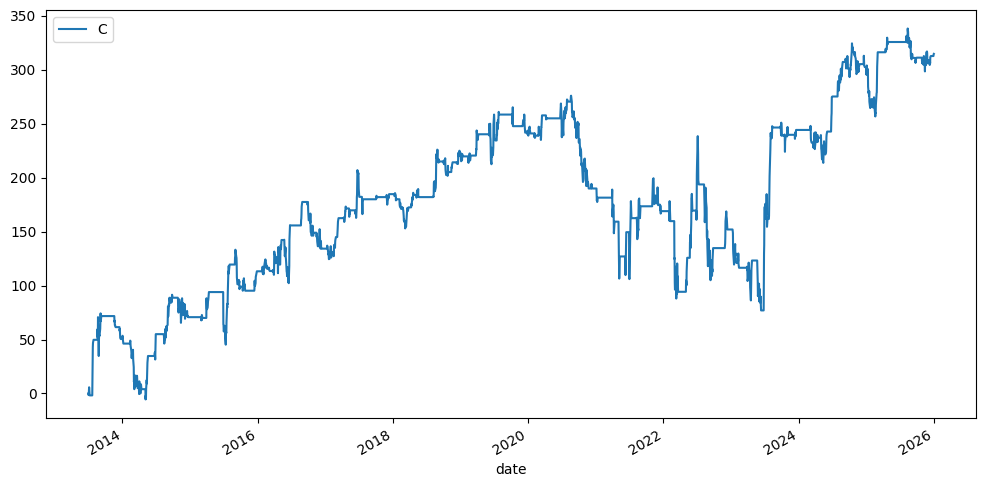

In [12]:
(-final_df).plot(figsize=(12,6))